In [26]:
from preprocessing import (
    remove_duplicates,
    get_numeric_columns,
    handle_outliers_iqr,
    correlation_feature_pruning,
    select_features_model_based
)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("../src")

from preprocessing import (
    remove_duplicates,
    get_numeric_columns,
    handle_outliers_iqr,
    correlation_feature_pruning
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
train_path = "../dataset/UNSW_NB15_training-set.csv"
test_path = "../dataset/UNSW_NB15_testing-set.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

Training shape: (175341, 45)
Testing shape: (82332, 45)


In [8]:
train.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [9]:
print(train.columns.tolist())

['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [10]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  str    
 3   service            175341 non-null  str    
 4   state              175341 non-null  str    
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  sinpkt       

In [11]:
print("Label distribution:")
print(train["label"].value_counts())

Label distribution:
label
1    119341
0     56000
Name: count, dtype: int64


In [12]:
print("Label percentage:")
print(
    train["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Label percentage:
label
1    68.06
0    31.94
Name: proportion, dtype: float64


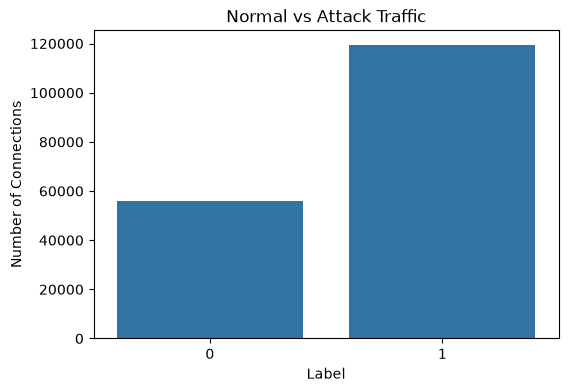

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(data=train, x="label")

plt.title("Normal vs Attack Traffic")
plt.xlabel("Label")
plt.ylabel("Number of Connections")

plt.show()

In [14]:
print("Attack category distribution:")
print(train["attack_cat"].value_counts())

Attack category distribution:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


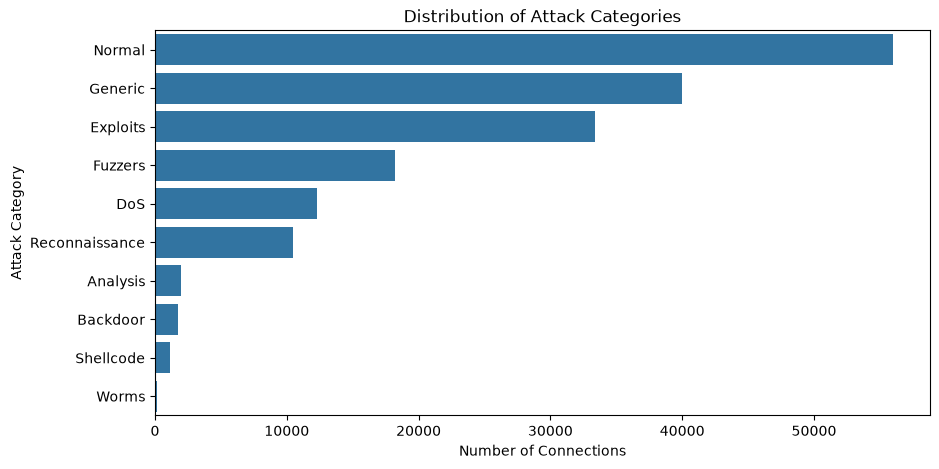

In [15]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=train,
    y="attack_cat",
    order=train["attack_cat"].value_counts().index
)

plt.title("Distribution of Attack Categories")
plt.xlabel("Number of Connections")
plt.ylabel("Attack Category")

plt.show()

In [16]:
print("Duplicate rows before removal:", train.duplicated().sum())

Duplicate rows before removal: 0


In [17]:
train = remove_duplicates(train)

Duplicate rows removed: 0
Rows remaining: 175341


In [18]:
print("Duplicate rows after removal:", train.duplicated().sum())

Duplicate rows after removal: 0


In [19]:
important_features = [
    "dur",
    "sbytes",
    "dbytes",
    "rate"
]

available_features = [
    feature
    for feature in important_features
    if feature in train.columns
]

print("Features available:")
print(available_features)

Features available:
['dur', 'sbytes', 'dbytes', 'rate']


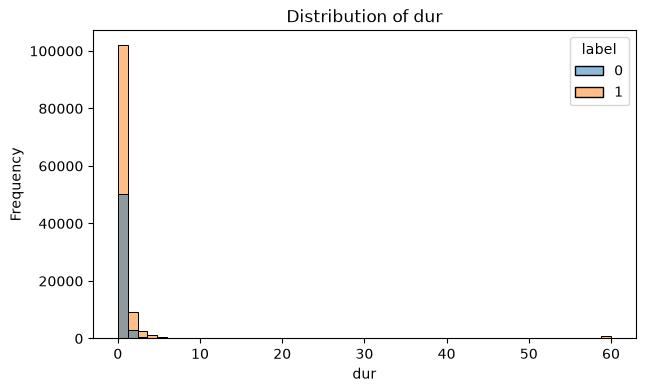

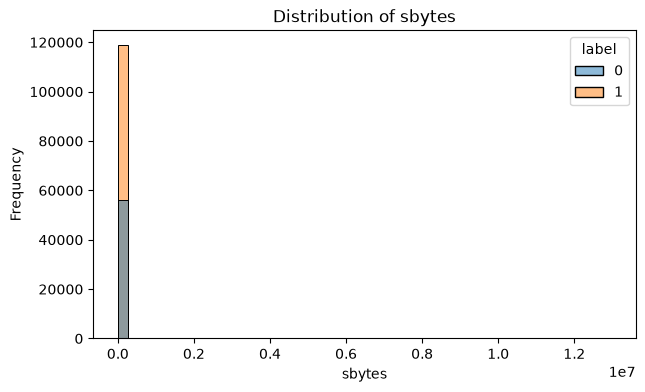

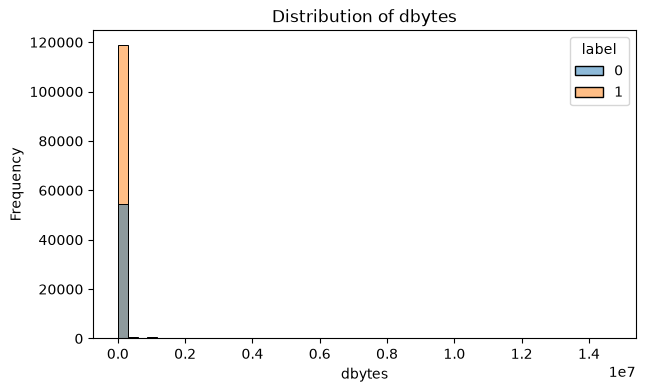

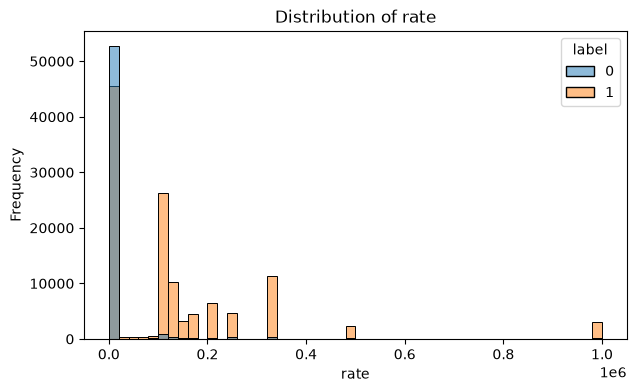

In [20]:
for feature in available_features:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=train,
        x=feature,
        hue="label",
        bins=50
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

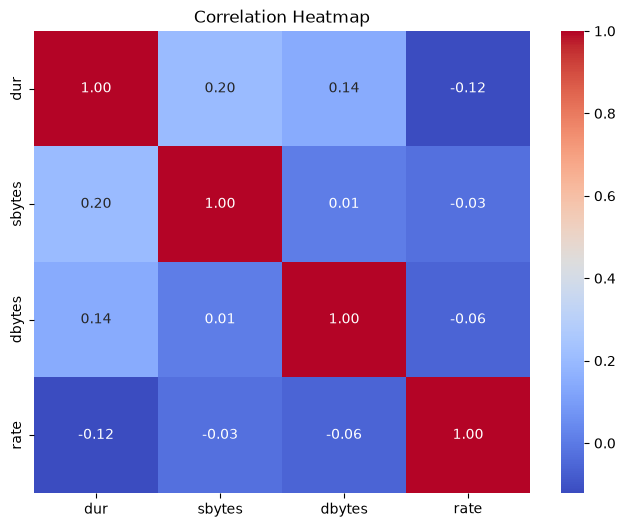

In [21]:
correlation_matrix = train[
    available_features
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

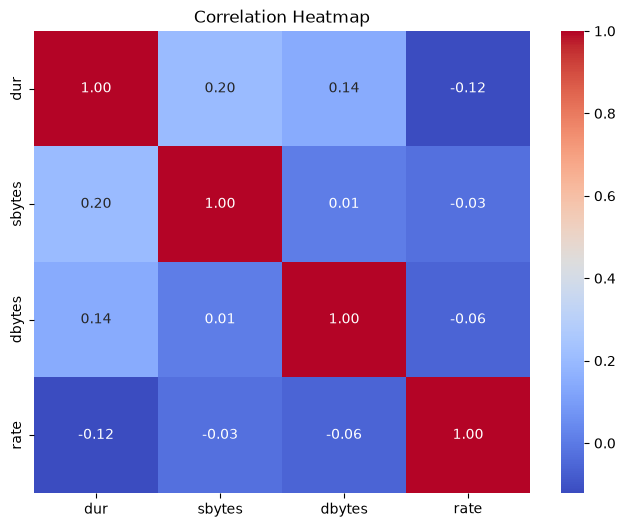

In [22]:
correlation_matrix = train[
    available_features
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [23]:
numeric_columns = get_numeric_columns(
    train,
    exclude_columns=["label"]
)

print("Number of numerical features:", len(numeric_columns))

Number of numerical features: 40


In [24]:
train_pruned, remaining_features = correlation_feature_pruning(
    train,
    numeric_columns,
    threshold=0.95
)

print("Remaining features:", len(remaining_features))
print(remaining_features)

Highly correlated features removed: 9
Removed features: ['sbytes', 'dbytes', 'sloss', 'dloss', 'dwin', 'ct_src_dport_ltm', 'ct_dst_src_ltm', 'ct_ftp_cmd', 'ct_srv_dst']
Remaining features: 31
['id', 'dur', 'spkts', 'dpkts', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_flw_http_mthd', 'ct_src_ltm', 'is_sm_ips_ports']


In [25]:
train_clean = handle_outliers_iqr(
    train_pruned,
    remaining_features
)

print("IQR outlier handling completed.")

IQR-based outlier handling completed.
IQR outlier handling completed.


In [27]:
# Prepare numeric feature matrix

feature_columns = [
    col for col in remaining_features
    if col in train_pruned.columns
]

X = train_pruned[feature_columns].copy()
y = train_pruned["label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (175341, 31)
y shape: (175341,)


In [28]:
X_selected, selector, selected_features = select_features_model_based(
    X,
    y,
    threshold="median"
)

c:\Users\amuly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Features before model selection: 31
Features after model selection: 16
Selected features:
['id', 'dur', 'dpkts', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sinpkt', 'dinpkt', 'synack', 'smean', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_sport_ltm']


In [ ]:
print("Final selected feature count:", len(selected_features))

print("\nFinal selected features:")
print(selected_features)